# Carregamento das bibliotecas

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

I0000 00:00:1775316765.828695    5066 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775316765.834475    5066 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775316766.402309    5066 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775316768.890777    5066 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

# Carregamento dos dados

In [2]:
from scipy.io import loadmat

dados = loadmat('Dados.mat')

print(dados.keys())

dict_keys(['__header__', '__version__', '__globals__', 'A'])


In [3]:
print(dados['A'])
print(dados['A'].shape)

[[15031.41]
 [12754.93]
 [16581.87]
 [15573.27]
 [16056.71]
 [16279.71]
 [15812.41]
 [16406.57]
 [15215.39]
 [15634.63]
 [15757.18]
 [15747.87]
 [13735.74]
 [15861.16]
 [15189.98]
 [ 5705.19]
 [16142.99]
 [16409.95]
 [13480.1 ]
 [12655.52]
 [14314.51]
 [16221.44]
 [15783.5 ]
 [16442.9 ]
 [16450.64]
 [16571.  ]
 [16978.1 ]
 [14974.75]
 [15373.42]
 [16155.25]
 [16418.15]
 [16749.53]
 [13154.81]
 [16422.71]
 [16245.62]
 [16087.99]
 [14525.89]
 [14263.13]
 [15867.35]
 [15927.83]
 [15533.32]
 [14953.39]
 [16074.39]
 [16488.89]
 [16220.98]
 [14928.18]
 [12038.96]
 [14463.45]
 [13119.6 ]
 [11663.77]
 [15615.32]
 [13034.86]
 [15971.75]
 [15786.16]
 [14530.55]
 [14568.05]
 [15884.03]
 [14511.91]
 [15696.07]
 [15619.17]
 [15497.15]
 [15791.78]
 [15833.04]
 [14605.04]
 [12926.68]
 [12195.81]
 [ 9277.27]
 [13569.41]
 [15216.03]
 [15369.85]
 [15195.72]
 [15088.29]
 [15430.53]
 [14954.8 ]
 [13094.69]
 [ 9099.95]
 [11207.23]
 [11992.55]
 [14646.85]
 [ 5350.36]
 [16195.19]
 [15569.98]
 [15748.61]
 [15

In [4]:
x = np.arange(1, len(dados['A']) + 1)
y = np.array(dados['A']/1000).flatten()
y.shape

(939,)

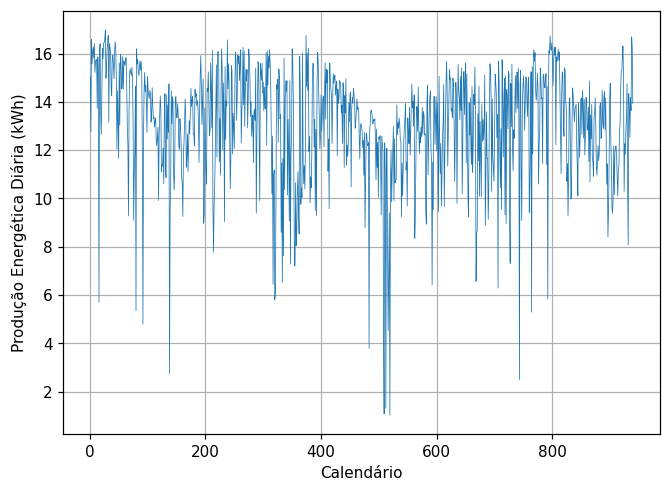

In [5]:
plt.figure(figsize=(7, 5), dpi=110)
plt.plot(x, y, linewidth=0.5)
plt.xlabel("Calendário")
plt.ylabel("Produção Energética Diária (kWh)")
plt.grid()


# Aplicação da média móvel nos dados

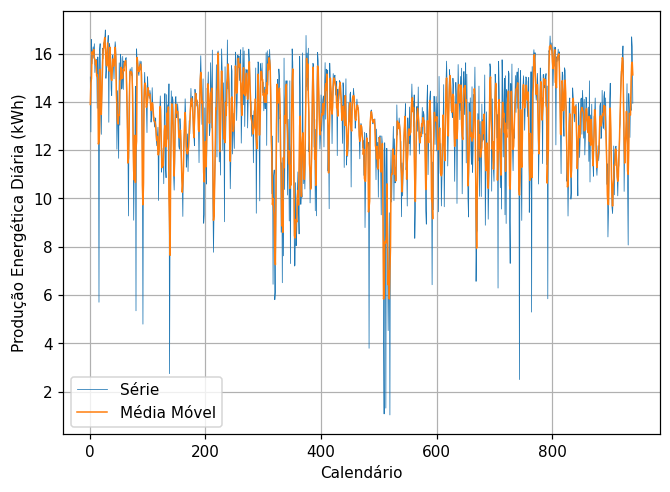

In [6]:
ymm = pd.Series(y).rolling(window=3, center=True, min_periods=1).mean().to_numpy()
#ymm = np.convolve(y, np.ones(3)/3, mode='same')
plt.figure(figsize=(7,5), dpi=110)
plt.plot(x, y, linewidth=0.5)
plt.plot(x, ymm, linewidth=1.0)
plt.xlabel("Calendário")
plt.ylabel("Produção Energética Diária (kWh)")
plt.legend(["Série", "Média Móvel"])
plt.grid()


# Divisão dos dados para treino e teste

In [7]:
from sklearn.model_selection import train_test_split

x_train , x_test , ymm_train , ymm_test = train_test_split (x, ymm, test_size =0.3, shuffle=False)

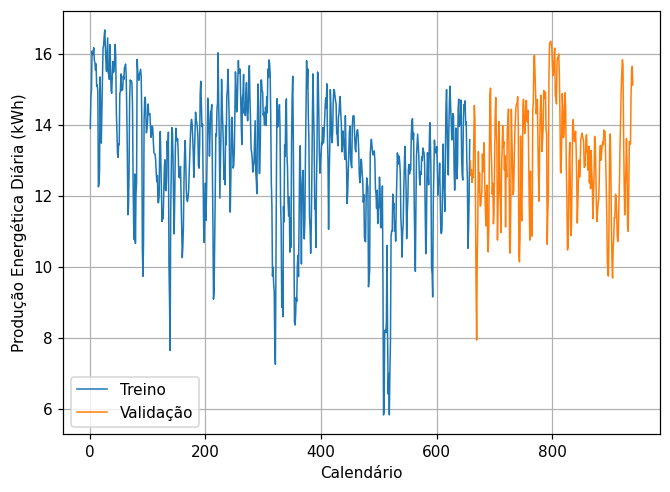

In [8]:
plt.figure(figsize=(7,5), dpi=110)
plt.plot(x_train, ymm_train, linewidth=1.0)
plt.plot(x_test, ymm_test, linewidth=1.0)
plt.xlabel("Calendário")
plt.ylabel("Produção Energética Diária (kWh)")
plt.grid()
plt.legend(["Treino", "Validação"])

# Normalização dos dados

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_ymm = MinMaxScaler()

ymm_train_scaled = scaler_ymm.fit_transform(ymm_train.reshape(-1, 1))
ymm_test_scaled = scaler_ymm.transform(ymm_test.reshape(-1, 1))



# Criação das janelas deslizantes (curto, médio e longo prazo)

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view

def gerar_datasets(serie, n_passado, n_futuro):
    tamanho_janela = n_passado + n_futuro
    janelas = sliding_window_view(serie, window_shape=tamanho_janela)
    
    x = janelas[:, :n_passado]
    
    y = janelas[:, n_passado:]
    
    return x, y

x_cp_train, y_target_cp_train = gerar_datasets(ymm_train_scaled.flatten(), 4, 1)
x_cp_test, y_target_cp_test = gerar_datasets(ymm_test_scaled.flatten(), 4, 1)

x_mp_train, y_target_mp_train = gerar_datasets(ymm_train_scaled.flatten(), 31, 7)
x_mp_test, y_target_mp_test = gerar_datasets(ymm_test_scaled.flatten(), 31, 7)

x_lp_train, y_target_lp_train = gerar_datasets(ymm_train_scaled.flatten(), 91, 30)
x_lp_test, y_target_lp_test = gerar_datasets(ymm_test_scaled.flatten(), 91, 30)


# Treinamento da rede neural